Import all the necessary libraries. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings("ignore")

from data_cleaning import clean_data
from aggregation import region_time, getting_outliers, growth_rate
from visualization import category_bar, sales_overtime, profit_sales, top_products

In [2]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize']= (12, 6)

In [3]:
df= pd.read_csv('Superstore.csv', encoding_errors ='ignore')

In [4]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


Identify the columns that need transformation(Order Date, Sales, Discount, Profit etc, and change to appropriate datatypes)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

Statistical analysis of the dataset

In [6]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


I created a function that removed duplicate values, Transformed the Order Date and Ship Date columns, calculated Profit Margin and calculated for negative order processing times

In [7]:
df_clean= clean_data(df)

Missing values:
 Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64
Duplicate values:
 0
Formating the Date Column...Converting type Object to type datetime

All Done...

Column Date Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Order Date  9994 non-null   datetime64[ns]
 1   Ship Date   9994 non-null   datetime64[ns]
dtypes: datetime64[ns](2)
memory usage: 156.3 KB
None

Calculating Profit Margin...

All done...
         Sales    Profit  Profit Margin
0     261.9600 

Summarised sales by region for easier analysis

In [8]:
sales_by_region_and_time = region_time(df_clean)


Calculating Sales per Region and Time...
Region   Order Date
Central  2014-01-31     1539.906
         2014-02-28     1233.174
         2014-03-31     5827.602
         2014-04-30     3712.340
         2014-05-31     4048.506
                         ...    
West     2017-08-31    25737.894
         2017-09-30    27907.037
         2017-10-31    21212.436
         2017-11-30    28941.787
         2017-12-31    29652.095
Name: Sales, Length: 192, dtype: float64


In [9]:
getting_outliers(df_clean)

Getting Outliers...
Empty DataFrame
Columns: [Row ID, Order ID, Order Date, Ship Date, Ship Mode, Customer ID, Customer Name, Segment, Country, City, State, Postal Code, Region, Product ID, Category, Sub-Category, Product Name, Sales, Quantity, Discount, Profit, Profit Margin, Order Processing Time]
Index: []

[0 rows x 23 columns]


There is a positive growth rate

In [10]:
growth_rate(df_clean)


Calculating Growth Rate
Order Date
2014-12-31          NaN
2015-12-31    -2.832227
2016-12-31    29.471521
2017-12-31    20.355962
Freq: A-DEC, Name: Sales, dtype: float64


Surmarised sales by category for easier comparison
Items in the Technology category make the most sales and have the biggest market share

                       Sales       Profit  Quantity
Category                                           
Furniture        741999.7953   18451.2728      8028
Office Supplies  719047.0320  122490.8008     22906
Technology       836154.0330  145454.9481      6939
Category
Furniture          32.300171
Office Supplies    31.301008
Technology         36.398821
Name: Sales, dtype: float64


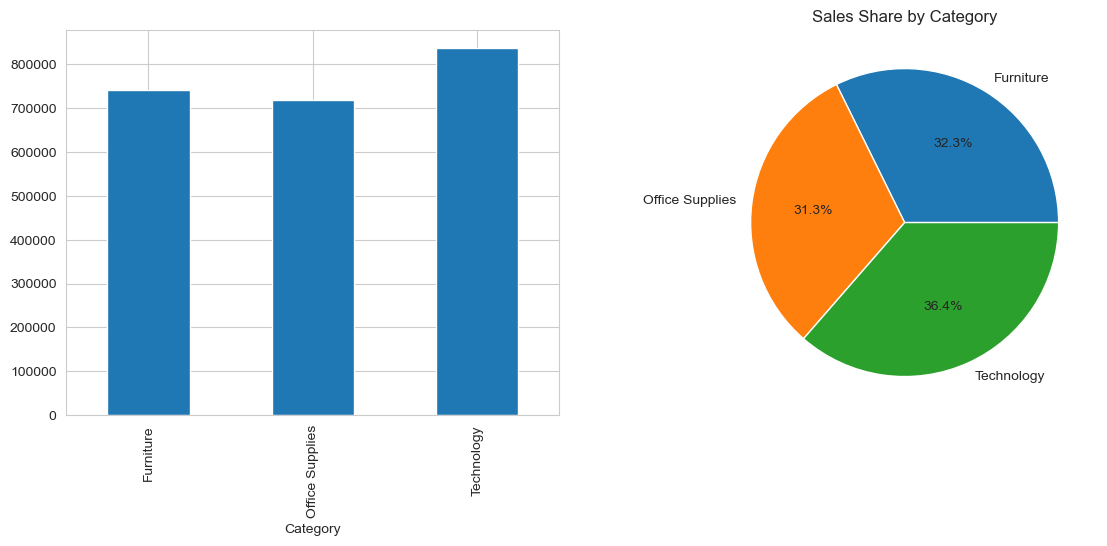

In [11]:
category_bar(df_clean)

The west region makes the most sales, while south region makes the least

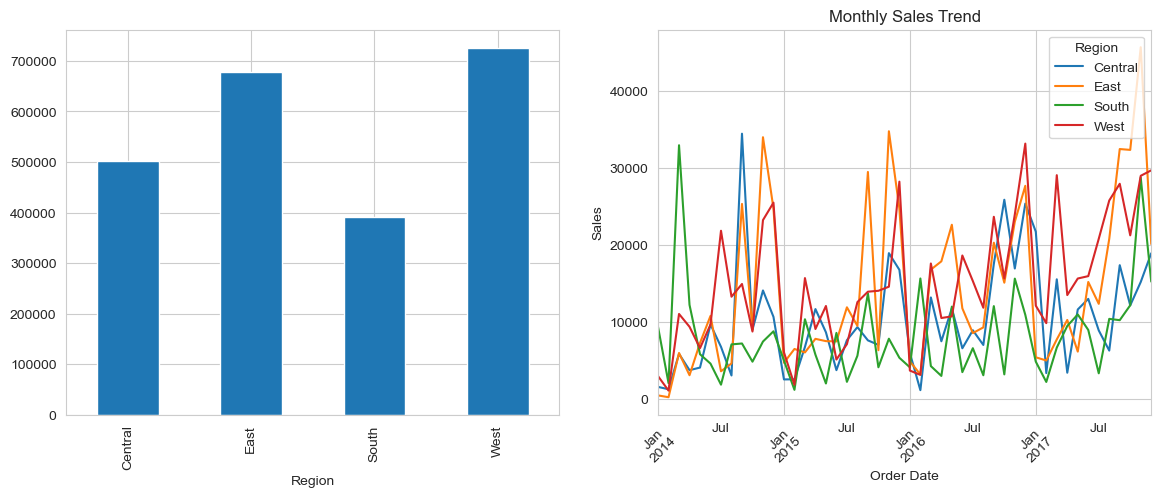

In [12]:
sales_overtime(df_clean)

Phones have the most number of sales

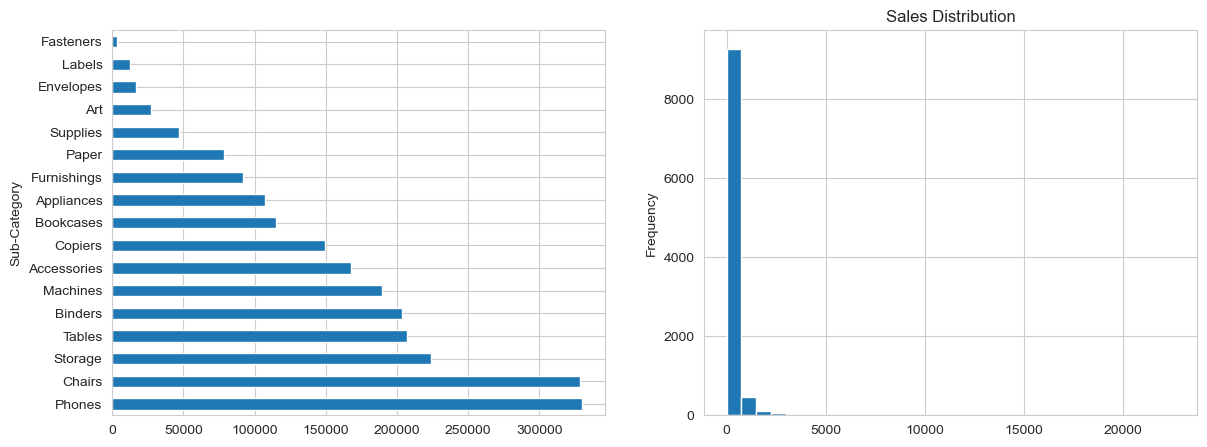

In [13]:
top_products(df_clean)

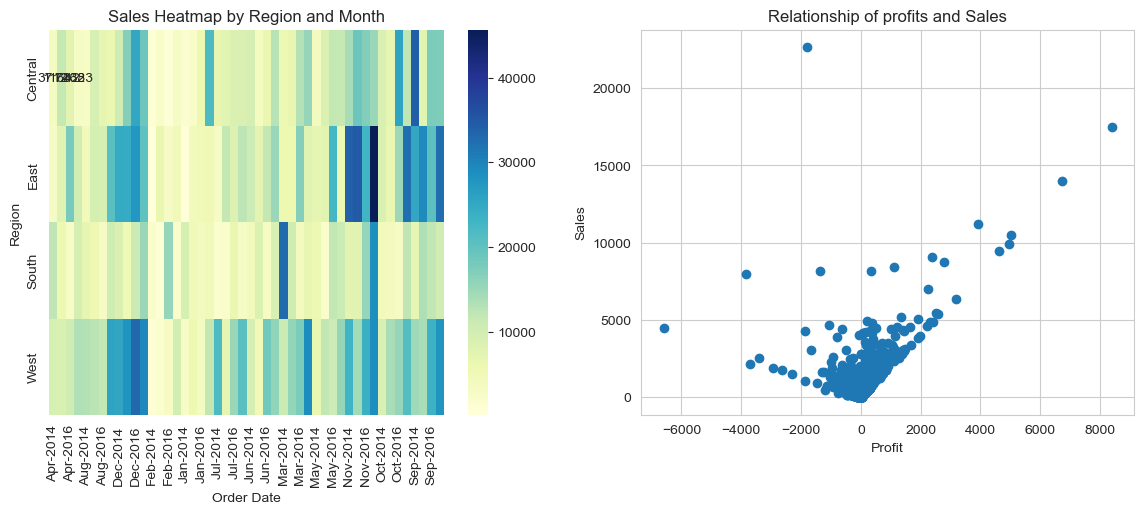

In [14]:
profit_sales(df_clean)